# Policy Comparison

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch.nn as nn

from battery_sim.battery.battery import Battery
from battery_sim.agents.policies.rule_based import ThresholdPolicy
from battery_sim.agents.policies.probabilistic import ProbabilisticThresholdPolicy
from battery_sim.agents.policies.continuous_probabilistic import ContinuousProbabilisticPolicy
from battery_sim.agents.policies.adp import ADPPolicy, default_features
from battery_sim.agents.policies.mppi import MPPIPolicy
from battery_sim.agents.policies.oracle import OraclePolicy
from battery_sim.models.median_reversion import MedianReversionModel
from battery_sim.optimization.policy_optimizer import evaluate_full
from battery_sim.utils.plotting import plot_eval, plot_daily_revenue, compare_policies

In [2]:
# Load data
train_df = pd.read_csv('../data/NEM_NSW1_2025-01-01_2025-12-31_1h.csv')
test_df = pd.read_csv('../data/NEM_NSW1_2026-01-01_2026-03-01_1h.csv')

print(f'Train: {len(train_df)} rows ({train_df.iloc[0, 0]} to {train_df.iloc[-1, 0]})')
print(f'Test:  {len(test_df)} rows ({test_df.iloc[0, 0]} to {test_df.iloc[-1, 0]})')

Train: 8736 rows (2025-01-01 10:00:00 to 2025-12-31 09:00:00)
Test:  1416 rows (2026-01-01 10:00:00 to 2026-03-01 09:00:00)


In [3]:
# Battery config
battery = Battery(
    capacity_mwh=2.0,
    max_charge_rate_mw=1.0,
    max_discharge_rate_mw=1.0,
    efficiency=0.9,
)

In [4]:
Q = 20
vals = np.quantile(train_df.price, q = [i/Q for i in range(1, Q)])
PARAM_GRID = {
    'buy_threshold':vals,
    'sell_threshold':vals,
}

## 1. Deterministic Threshold Policy

In [5]:
det_policy = ThresholdPolicy(
    buy_threshold=50.0,
    sell_threshold=200.0,
    charge_rate=1.0,
    discharge_rate=1.0,
)

# Learn optimal thresholds on training data
det_policy.learn(
    train_data=train_df, 
    battery=battery, 
    num_iters=25, 
    window_len=24 * 7,
    param_grid=PARAM_GRID
)
print(f'Learned buy_threshold: {det_policy.buy_threshold}')
print(f'Learned sell_threshold: {det_policy.sell_threshold}')

Learned buy_threshold: 132.1525
Learned sell_threshold: 213.13146


## 2. Probabilistic Threshold Policy

In [6]:
# price_model = MedianReversionModel(window_days=30, interval_minutes=60)

# prob_policy = ProbabilisticThresholdPolicy(
#     model=price_model,
#     buy_threshold=50.0,
#     sell_threshold=200.0,
#     charge_rate=1.0,
#     discharge_rate=1.0,
# )

# # Learn: fits model + grid searches thresholds
# prob_policy.learn(
#     train_data=train_df, 
#     battery=battery, 
#     num_iters=10, 
#     window_len=24 * 7,
#     param_grid=PARAM_GRID
# )
# print(f'Learned buy_threshold: {prob_policy.buy_threshold}')
# print(f'Learned sell_threshold: {prob_policy.sell_threshold}')

## 3. Continuous Probabilistic Policy

In [7]:
cont_model = MedianReversionModel(window_days=30, interval_minutes=60)

cont_policy = ContinuousProbabilisticPolicy(
    model=cont_model,
    buy_threshold=50.0,
    sell_threshold=200.0,
    charge_rate=1.0,
    discharge_rate=1.0,
)

cont_policy.learn(
    train_data=train_df,
    battery=battery,
    num_iters=10,
    window_len=24 * 7,
    param_grid=PARAM_GRID,
)
print(f'Learned buy_threshold: {cont_policy.buy_threshold}')
print(f'Learned sell_threshold: {cont_policy.sell_threshold}')

Learned buy_threshold: 61.613958000000004
Learned sell_threshold: 168.311665


## 4. ADP (Approximate Dynamic Programming) Policy

  iter 1/10  loss=2924.5291
  iter 2/10  loss=489.3417
  iter 3/10  loss=3515.2268
  iter 4/10  loss=4096.5269
  iter 5/10  loss=1774.4032
  iter 6/10  loss=782.0353
  iter 7/10  loss=1232.3268
  iter 8/10  loss=1311.9275
  iter 9/10  loss=3447.9678
  iter 10/10  loss=3773.0613


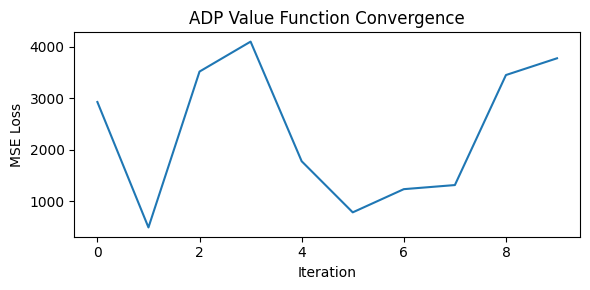

In [8]:
# Single-layer linear value function: 2 features (price, soc) -> 1
adp_net = nn.Linear(2, 1)
adp_policy = ADPPolicy(
    net=adp_net,
    feature_fn=default_features,
    charge_rate=1.0,
    discharge_rate=1.0,
)

adp_policy.learn(
    train_data=train_df,
    battery=battery,
    num_iters=10,
    window_len=24 * 7,
    n_windows=25,
)

# Plot convergence
fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(adp_policy.loss_history)
ax.set(xlabel='Iteration', ylabel='MSE Loss', title='ADP Value Function Convergence')
plt.tight_layout()
plt.show()

## 5. MPPI (Model Predictive Path Integral) Policy

In [9]:
mppi_model = MedianReversionModel(window_days=30, interval_minutes=60)
mppi_policy = MPPIPolicy(
    model=mppi_model,
    battery=battery,
    horizon=12,
    n_samples=100,
    n_trajectories=50,
)

mppi_policy.learn(
    train_data=train_df,
    battery=battery,
    num_iters=25,
    window_len=24 * 7,
)
print(f'Tuned noise_sigma: {mppi_policy.noise_sigma}')
print(f'Tuned temperature: {mppi_policy.temperature}')

Tuned noise_sigma: 0.5
Tuned temperature: 0.5


## 6. Oracle (Perfect Foresight)

In [10]:
oracle = OraclePolicy(price_data=test_df, battery=battery)
print(f'Oracle solved LP with {len(test_df) - 1} tradeable steps')

Oracle solved LP with 1415 tradeable steps


## 7. Evaluate on Test Set

In [11]:
# Re-fit models on train data before test evaluation
mppi_model.fit(train_df)
cont_model.fit(train_df)

det_eval = evaluate_full('Deterministic Threshold', det_policy, test_df, battery)
cont_eval = evaluate_full('Continuous Probabilistic', cont_policy, test_df, battery)
adp_eval = evaluate_full('ADP (Linear)', adp_policy, test_df, battery)
mppi_eval = evaluate_full('MPPI', mppi_policy, test_df, battery)
oracle_eval = evaluate_full('Oracle', oracle, test_df, battery)

all_evals = [det_eval, cont_eval, adp_eval, mppi_eval, oracle_eval]
for e in all_evals:
    print(e.summary())
    print()

Deterministic Threshold:
  Cumulative revenue: $9,102.46
  Mean daily revenue: $151.71 (+/- $774.29)
  Total steps: 1415

Continuous Probabilistic:
  Cumulative revenue: $9,226.47
  Mean daily revenue: $153.77 (+/- $707.05)
  Total steps: 1415

ADP (Linear):
  Cumulative revenue: $1,598.71
  Mean daily revenue: $26.65 (+/- $50.53)
  Total steps: 1415

MPPI:
  Cumulative revenue: $14,122.56
  Mean daily revenue: $235.38 (+/- $752.32)
  Total steps: 1415

Oracle:
  Cumulative revenue: $31,721.37
  Mean daily revenue: $528.69 (+/- $1,478.07)
  Total steps: 1415



## 8. Detailed Plots

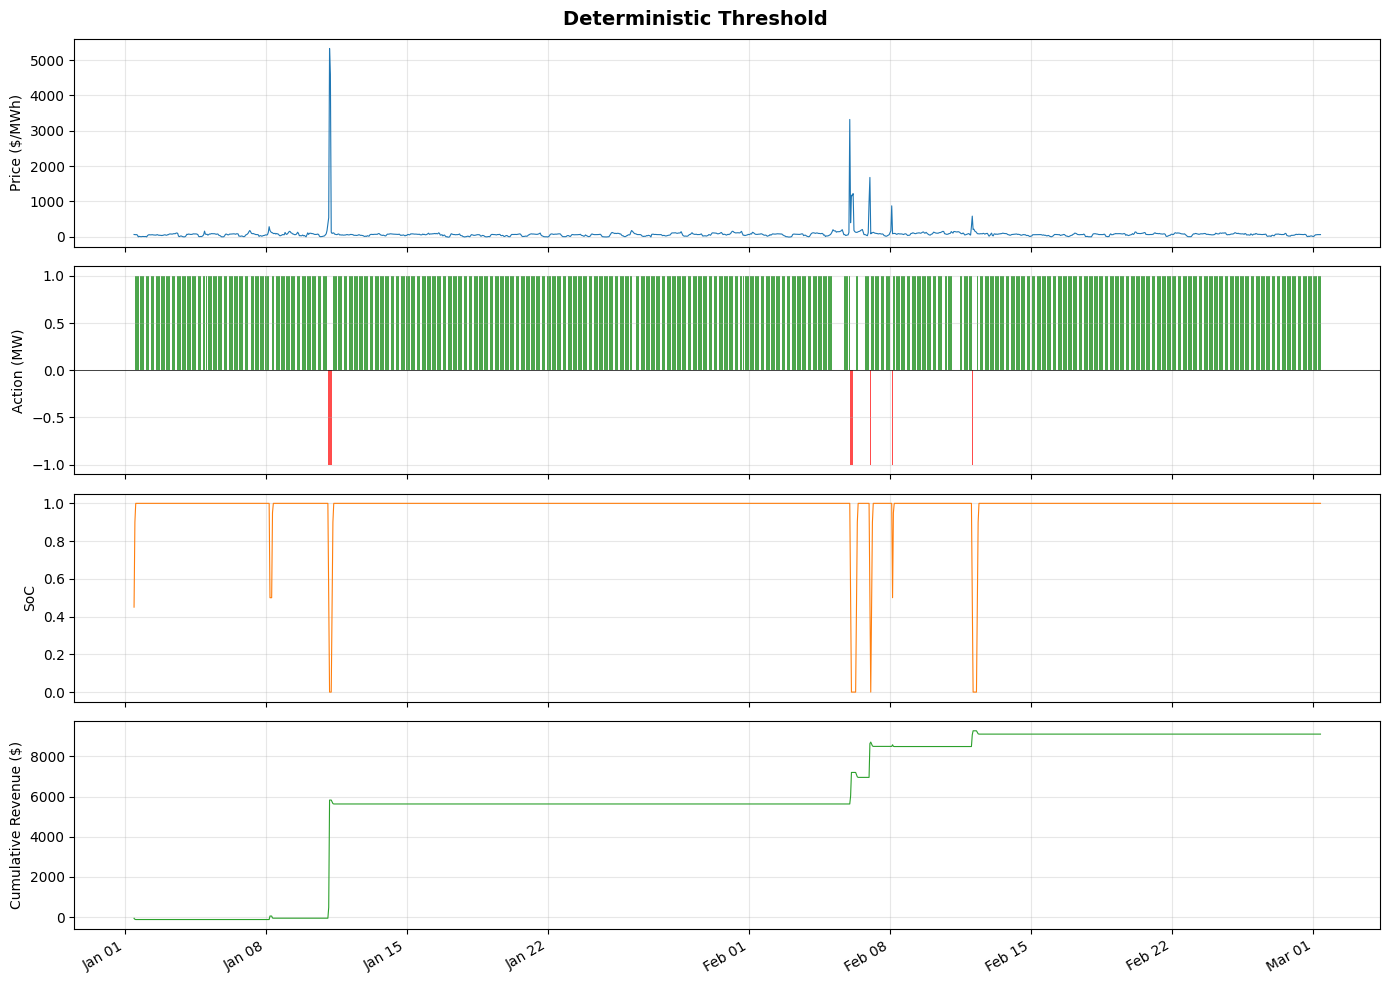

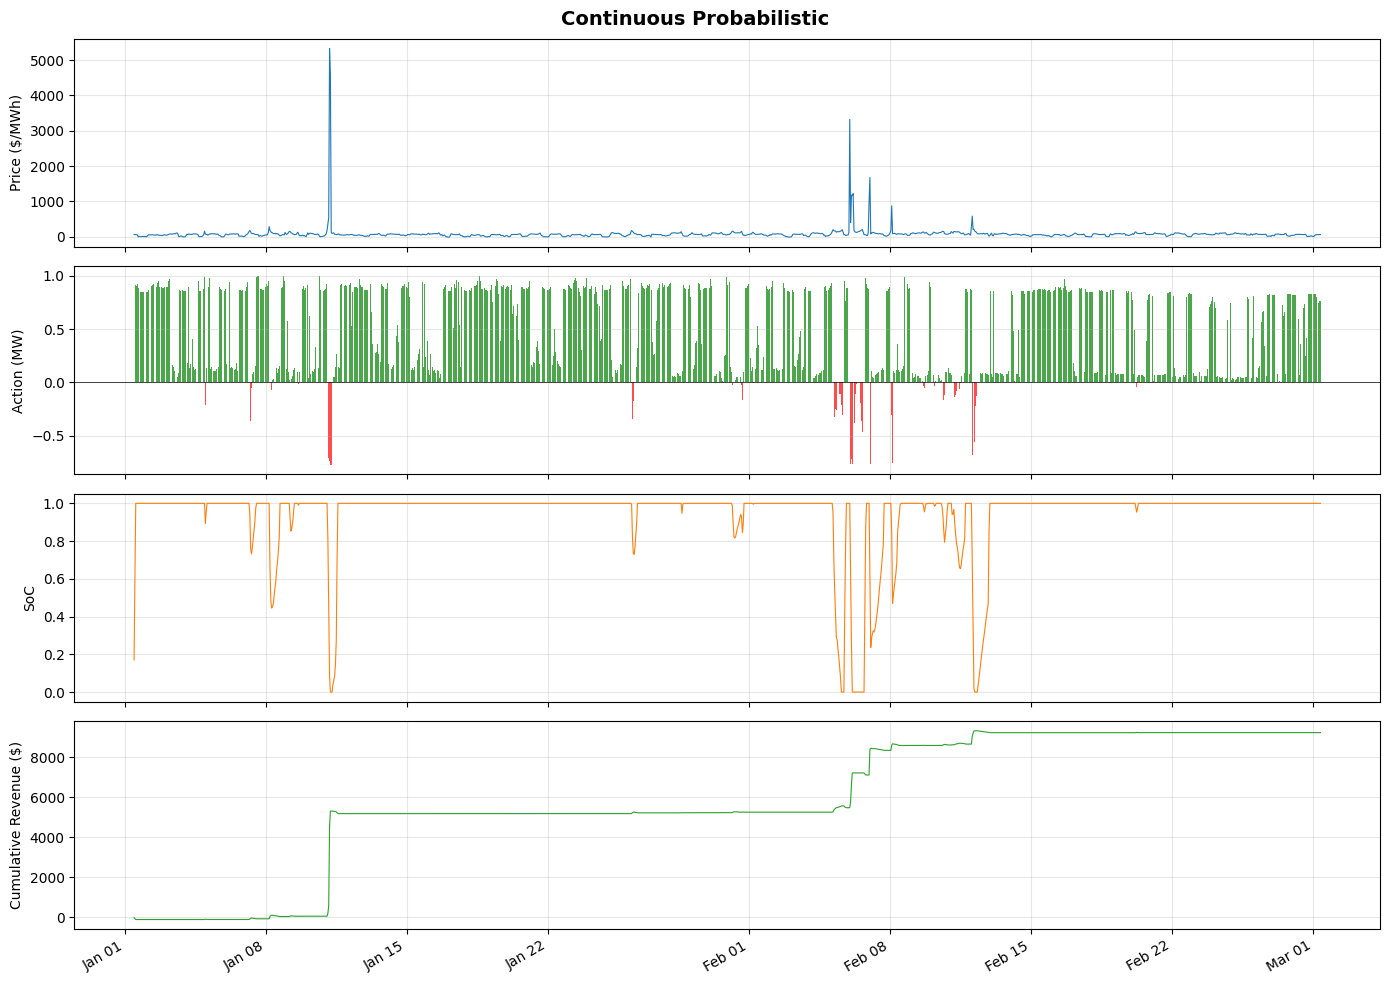

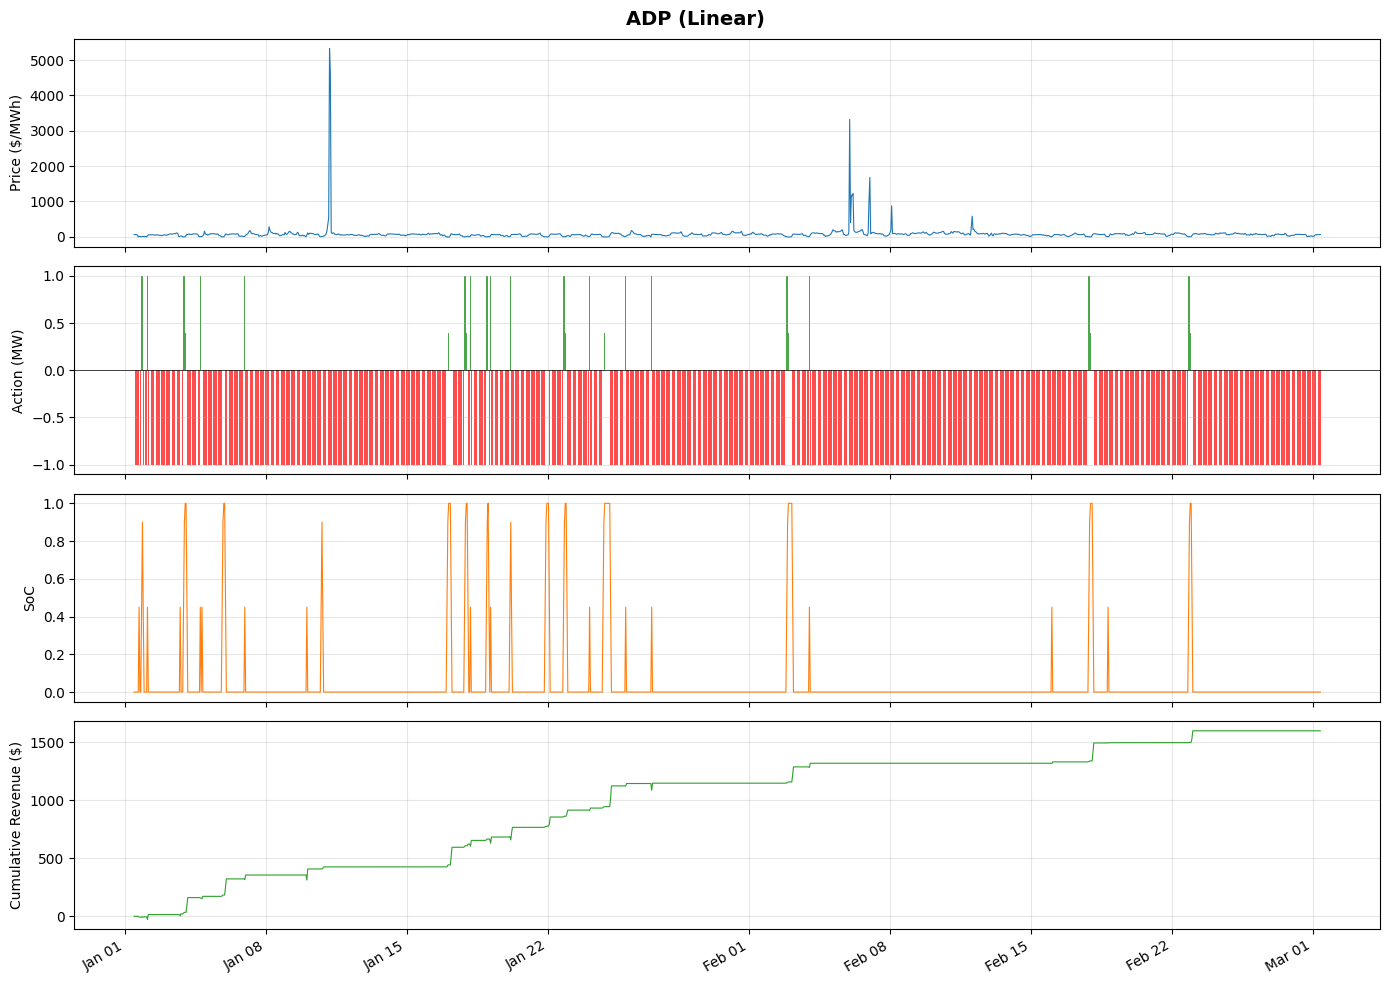

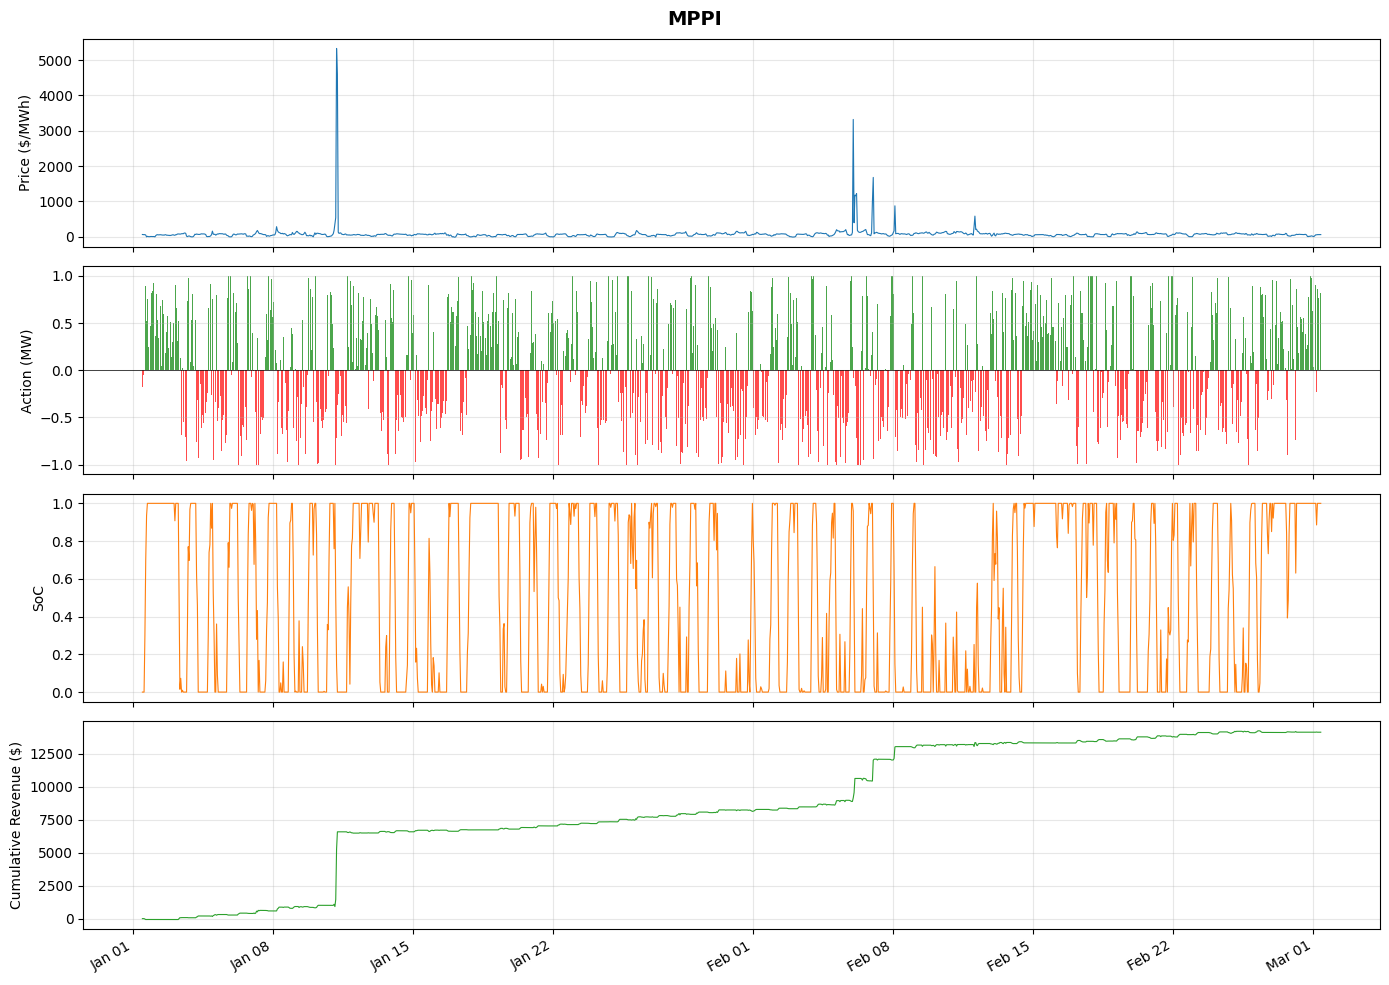

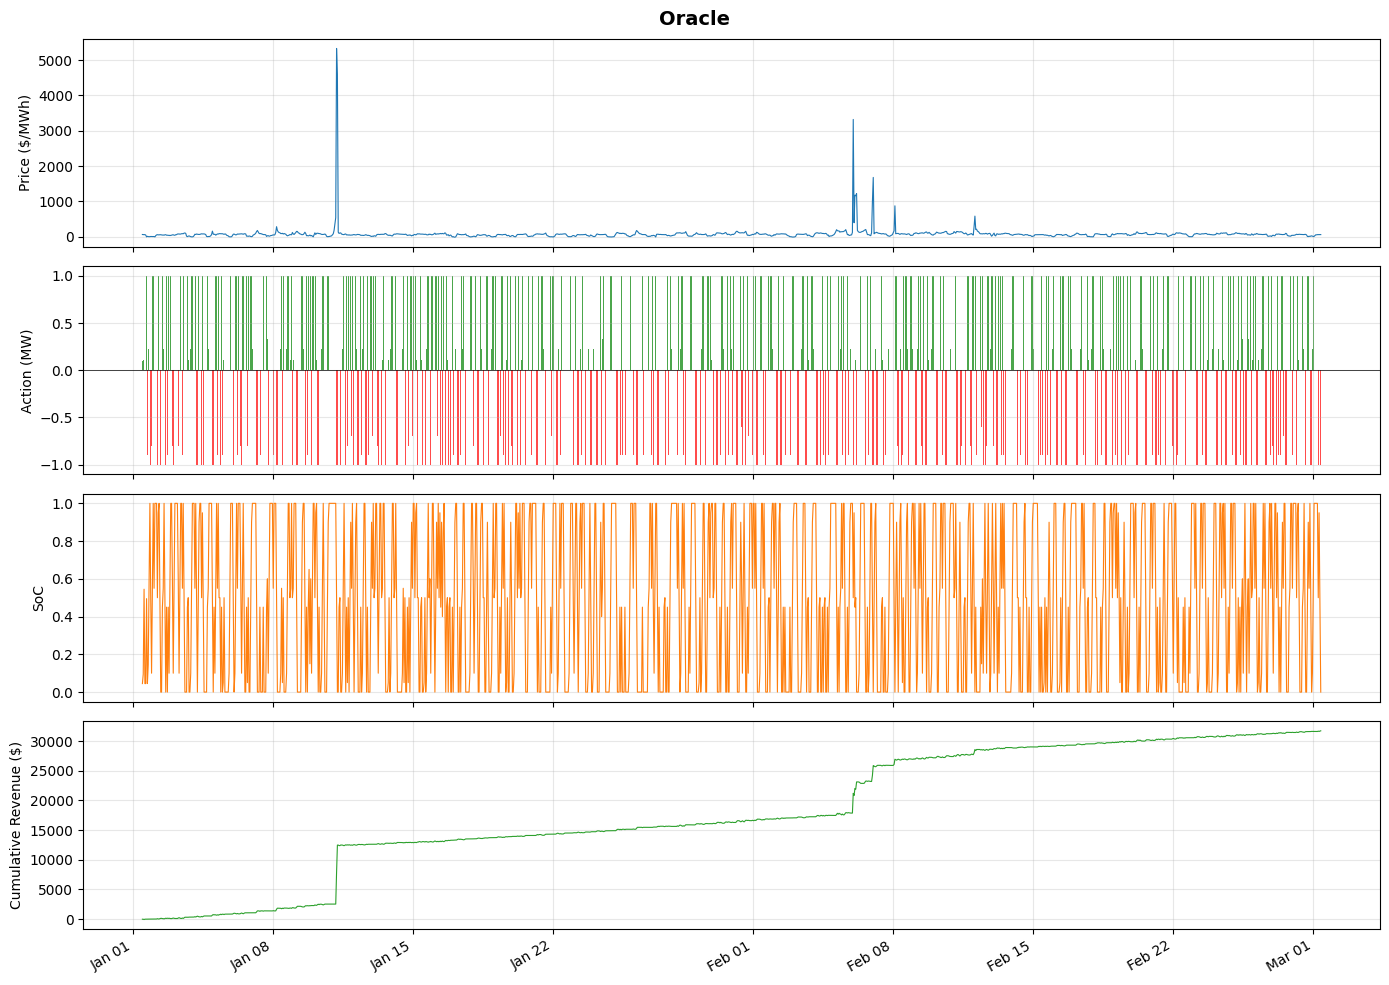

In [12]:
for e in all_evals:
    plot_eval(e)
    plt.show()

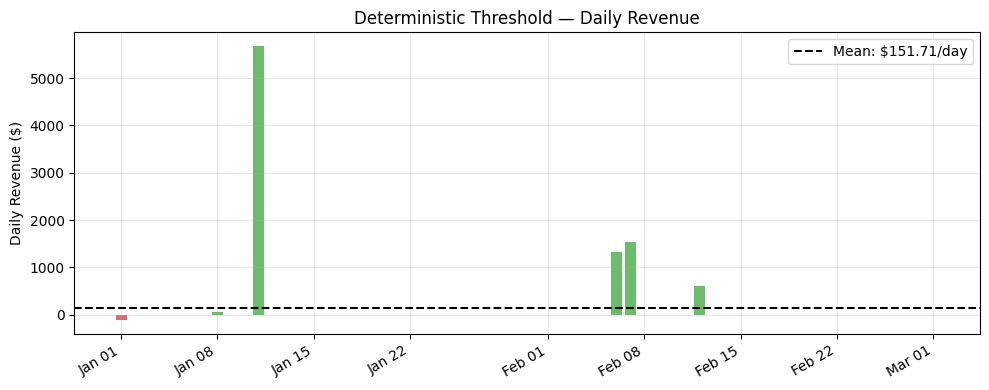

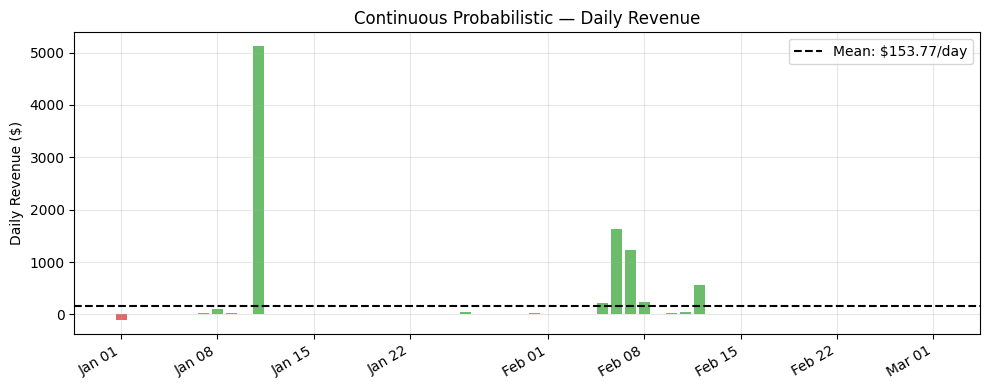

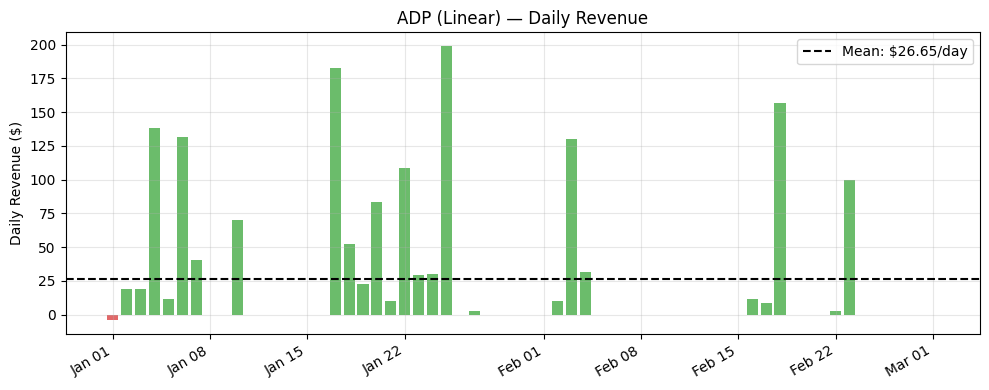

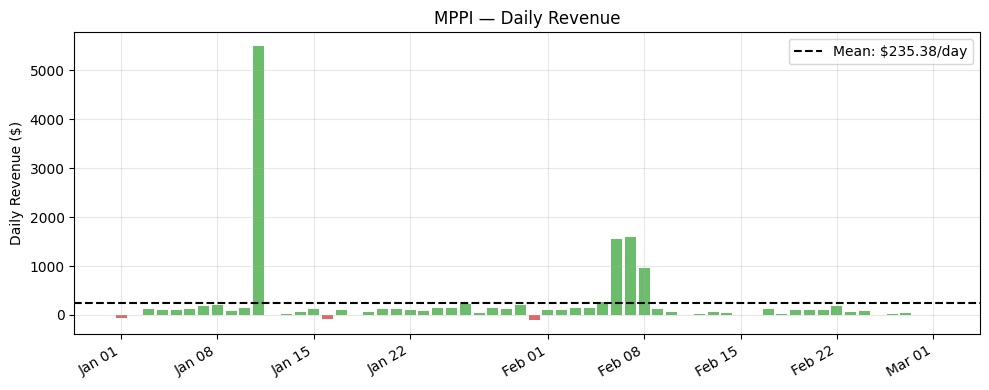

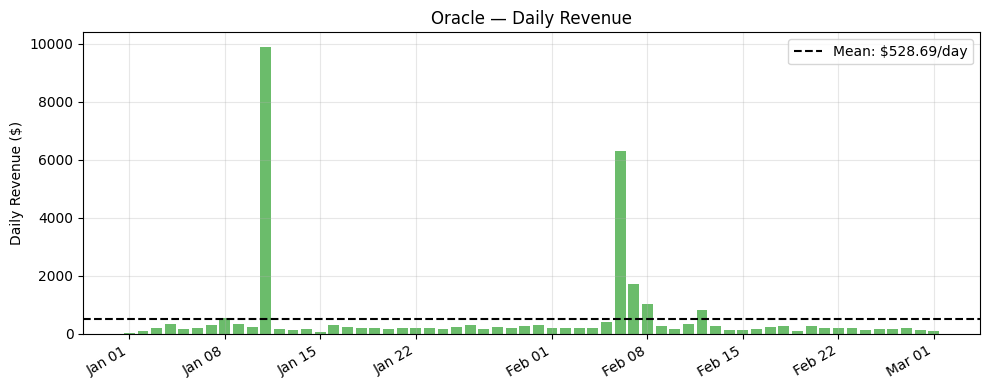

In [13]:
for e in all_evals:
    plot_daily_revenue(e)
    plt.show()

## 9. Policy Comparison

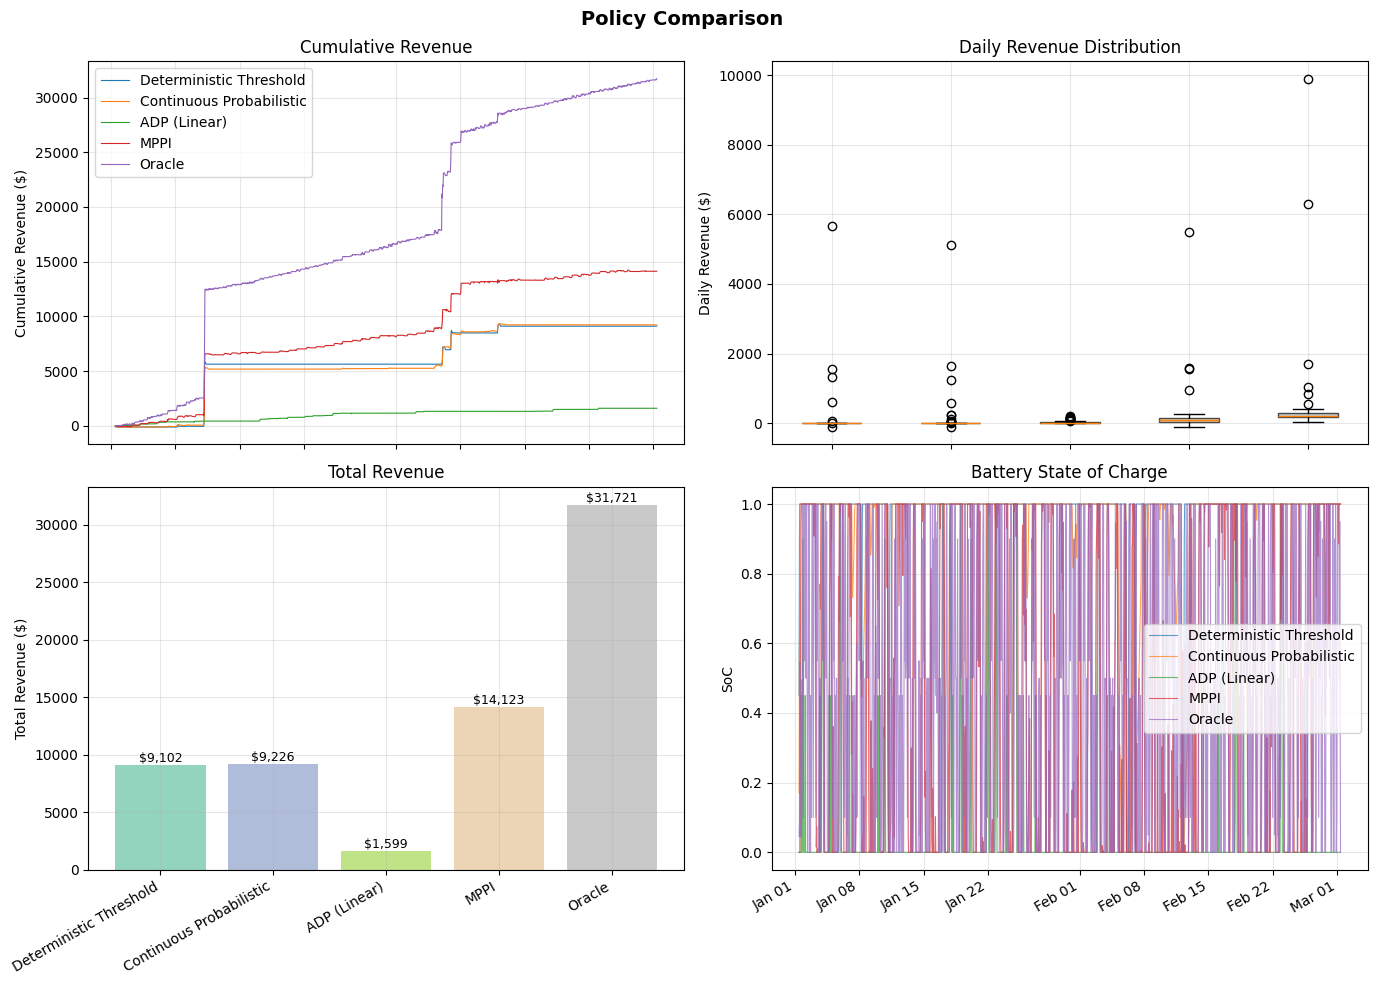

In [14]:
compare_policies(all_evals)
plt.show()